In [11]:
import matplotlib.pyplot as plt
import numpy as np

from auv_planning.oscar_loader import load_oscar_region


In [12]:
grid = load_oscar_region(
    "../data/raw/oscar_currents_final_20250915.nc",
    min_lat=32,
    max_lat=38,
    min_lon=-126,
    max_lon=-120,
)

print("Grid:", grid.current_u.shape)
print("Usable ocean cells:", grid.traversable.sum())

Grid: (25, 25)
Usable ocean cells: 516


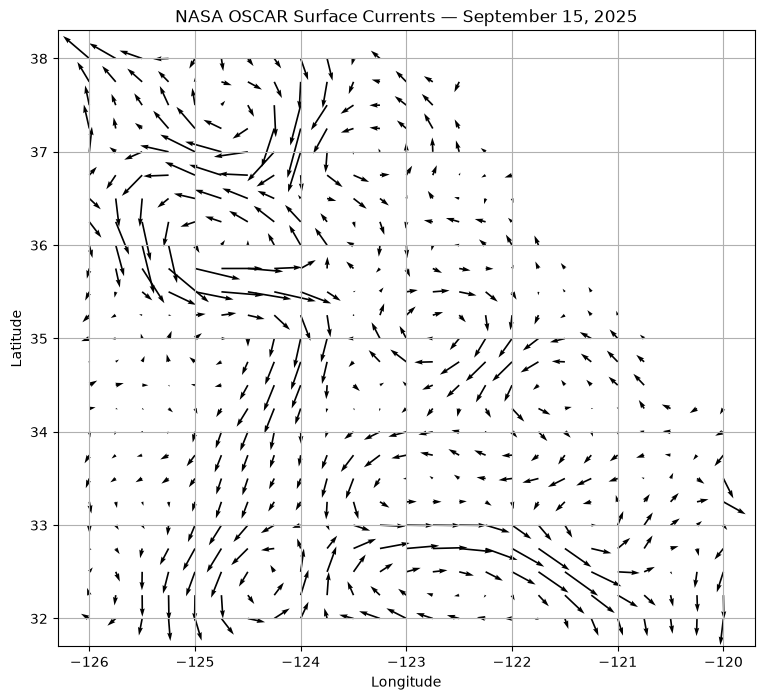

In [13]:
lon, lat = np.meshgrid(
    grid.longitudes,
    grid.latitudes,
)

u = np.where(
    grid.traversable,
    grid.current_u,
    np.nan,
)

v = np.where(
    grid.traversable,
    grid.current_v,
    np.nan,
)

plt.figure(figsize=(9, 8))

plt.quiver(
    lon,
    lat,
    u,
    v,
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("NASA OSCAR Surface Currents — September 15, 2025")
plt.grid()

plt.show()

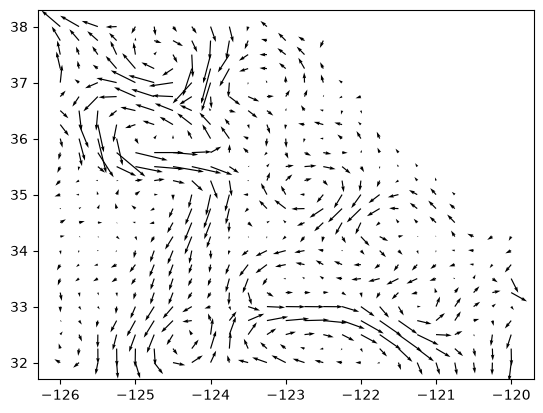

In [14]:
plt.quiver(lon, lat, u, v)

In [15]:
# Show the grid indices corresponding to some usable ocean cells.
for y in range(grid.height):
    for x in range(grid.width):
        if grid.traversable[y, x]:
            if x % 6 == 0 and y % 6 == 0:
                print(
                    (x, y),
                    "→",
                    f"({grid.latitudes[y]:.2f}, "
                    f"{grid.longitudes[x]:.2f})"
                )

(0, 0) → (32.00, -126.00)
(6, 0) → (32.00, -124.50)
(12, 0) → (32.00, -123.00)
(18, 0) → (32.00, -121.50)
(24, 0) → (32.00, -120.00)
(0, 6) → (33.50, -126.00)
(6, 6) → (33.50, -124.50)
(12, 6) → (33.50, -123.00)
(18, 6) → (33.50, -121.50)
(24, 6) → (33.50, -120.00)
(0, 12) → (35.00, -126.00)
(6, 12) → (35.00, -124.50)
(12, 12) → (35.00, -123.00)
(18, 12) → (35.00, -121.50)
(0, 18) → (36.50, -126.00)
(6, 18) → (36.50, -124.50)
(12, 18) → (36.50, -123.00)
(0, 24) → (38.00, -126.00)
(6, 24) → (38.00, -124.50)


In [16]:
from auv_planning.astar import astar
from auv_planning.current_aware_astar import current_aware_astar

start = (0, 6)
goal = (18, 6)

shortest_path = astar(grid, start, goal)

energy_path = current_aware_astar(
    grid,
    start,
    goal,
    ground_speed=1.0,
    power_coefficient=200.0,
)

print("Shortest path:", shortest_path)
print("Energy-aware path:", energy_path)

print("\nShortest path cells:", len(shortest_path))
print("Energy-aware path cells:", len(energy_path))

Shortest path: [(0, 6), (1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6), (7, 6), (8, 6), (9, 6), (10, 6), (11, 6), (12, 6), (13, 6), (14, 6), (15, 6), (16, 6), (17, 6), (18, 6)]
Energy-aware path: [(0, 6), (0, 5), (1, 4), (2, 3), (3, 2), (4, 1), (5, 0), (6, 0), (7, 0), (8, 1), (9, 2), (10, 3), (11, 3), (12, 3), (13, 3), (14, 3), (15, 3), (16, 3), (17, 3), (18, 3), (19, 4), (19, 5), (18, 6)]

Shortest path cells: 19
Energy-aware path cells: 23
